# YaDaYo KaKoI

In [ ]:
import yfinance as yf

# Download historical data for Bitcoin (BTC-USD ticker)
btc_data = yf.download("BTC-USD", start="2019-11-10", end="2024-11-10")

# Save to CSV
btc_data.to_csv("NEW.csv")


/tmp/ipython-input-110555690.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_data = yf.download("BTC-USD", start="2019-11-10", end="2024-11-10")
[*********************100%***********************]  1 of 1 completed


**Sai--kYoU**
**This Python script uses Keras to predict Bitcoin prices.**

**I picked a Recurrent Neural Network and a Bitcoin dataset.**

In [ ]:
# install pydrive
!pip install -U -q Pydrive

In [ ]:
# install mlflow
!pip install -U -q mlflow

In [ ]:
# import packages
import mlflow
import mlflow.keras
import mlflow.tracking
from mlflow import pyfunc
from mlflow.models import Model

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from keras.layers import LSTM
from keras.layers import Dense
from keras.models import Sequential

from sklearn.preprocessing import MinMaxScaler

from google.colab import auth
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from oauth2client.client import GoogleCredentials

In [ ]:
### read in the dataset to a dataframe
pd.set_option('display.max_columns', 8)
pd.set_option('display.width', 1000)
df = pd.read_csv('NEW.csv')

print(df.head())
print('')
print(df.shape)
print('')

                       Price        Adj Close            Close             High              Low             Open       Volume
0                     Ticker          BTC-USD          BTC-USD          BTC-USD          BTC-USD          BTC-USD      BTC-USD
1                       Date              NaN              NaN              NaN              NaN              NaN          NaN
2  2019-11-10 00:00:00+00:00  9055.5263671875  9055.5263671875   9103.826171875   8806.162109375  8812.4892578125  20587919881
3  2019-11-11 00:00:00+00:00  8757.7880859375  8757.7880859375   9081.279296875  8700.6083984375    9056.91796875  20265510765
4  2019-11-12 00:00:00+00:00   8815.662109375   8815.662109375  8853.7685546875   8685.427734375   8759.751953125  20309769107

(1829, 7)



In [ ]:
### Encode the date
# Read the CSV, treating the first column as the index
df = pd.read_csv('NEW.csv', index_col=0, header=[0, 1])

# Flatten the multi-level columns for easier access
df.columns = ['_'.join(col) for col in df.columns]

# Reset the index to make 'Date' a column
df = df.reset_index()  # This will create a 'Date' column from the index

# Convert the 'Date' column to datetime objects, handling errors
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows with invalid dates (NaT)
df = df.dropna(subset=['Date'])

# Extract the date part from the 'Date' column
df['Date_Only'] = df['Date'].dt.date

# Group by 'Date_Only' and calculate the mean 'Adj Close'
# Assuming the 'Adj Close' column is now named 'Adj Close_BTC-USD'
Real_Price = df.groupby('Date_Only')['Adj Close_BTC-USD'].mean()

print(Real_Price.head())
print('')
print(Real_Price.shape)
print('')

Date_Only
2019-11-10    9055.526367
2019-11-11    8757.788086
2019-11-12    8815.662109
2019-11-13    8808.262695
2019-11-14    8708.094727
Name: Adj Close_BTC-USD, dtype: float64

(1827,)



In [ ]:
# ### Encode the date
# # Reset the index to make 'Date' a column
# df = df.reset_index()

# # Convert the 'Date' column to datetime objects
# df['Date'] = pd.to_datetime(df['Date'])

# # Extract the date part from the 'Date' column
# df['Date_Only'] = df['Date'].dt.date

# # Group by 'Date_Only' and calculate the mean 'Adj Close'
# Real_Price = df.groupby('Date_Only')['Adj Close'].mean()

# print(Real_Price.head())
# print('')
# print(Real_Price.shape)
# print('')

In [ ]:
# ### encode the date
# # df['date'] = pd.to_datetime(df['Timestamp'], unit ='s').dt.date
# # group = df.groupby('date')
# # Real_Price = group['Weighted_Price'].mean()
# df['Date'] = pd.to_datetime(df['Date'])

# # Group by the 'Date' column and calculate the mean of 'Adj Close'
# # You can change 'Adj Close' to 'Close' if needed
# Real_Price = df.groupby(df['Date'].dt.date)['Adj Close'].mean()

# # # Display the result
# # print(Real_Price.head())
# # print('')
# # print(Real_Price.shape)
# # print('')

# print(Real_Price.head())
# print('')
# print(Real_Price.shape)
# print('')

In [ ]:
### split dataset into train and test sets
prediction_days = 30
df_train = Real_Price[:len(Real_Price) - prediction_days]
df_test = Real_Price[len(Real_Price) - prediction_days:]

print(df_train.head())
print('')
print(df_train.shape)
print('')
print(df_test.head())
print('')
print(df_test.shape)
print('')

Date_Only
2019-11-10    9055.526367
2019-11-11    8757.788086
2019-11-12    8815.662109
2019-11-13    8808.262695
2019-11-14    8708.094727
Name: Adj Close_BTC-USD, dtype: float64

(1797,)

Date_Only
2024-10-11    62445.089844
2024-10-12    63193.023438
2024-10-13    62851.375000
2024-10-14    66046.125000
2024-10-15    67041.109375
Name: Adj Close_BTC-USD, dtype: float64

(30,)



In [ ]:
### preprocess the data by reshaping it
training_set = df_train.values
training_set = np.reshape(training_set, (len(training_set),1))

print("Training set after reshaping:")
print('')
print(training_set)
print('')
print(training_set.shape)
print('')

Training set after reshaping:

[[ 9055.52636719]
 [ 8757.78808594]
 [ 8815.66210938]
 ...
 [62131.96875   ]
 [60582.1015625 ]
 [60274.5       ]]

(1797, 1)



In [ ]:
### preprocess the data by scaling it
sc = MinMaxScaler()
training_set = sc.fit_transform(training_set)
X_train = training_set[0 : len(training_set) -1]
y_train = training_set[1 : len(training_set)]
X_train = np.reshape(X_train, (len(X_train),1, 1))

print("Scaled training set:")
print('')
print(training_set)
print('')
print("Define X_train")
print('')
print(X_train)
print('')
print(X_train.shape)
print("Define y_train:")
print('')
print(y_train)
print('')
print(y_train.shape)
print('')
print("X_train reshaped:")
print('')
print(X_train)
print('')
print(X_train.shape)
print('')

Scaled training set:

[[0.05997028]
 [0.05559902]
 [0.0564487 ]
 ...
 [0.83921458]
 [0.81646013]
 [0.81194406]]

Define X_train

[[[0.05997028]]

 [[0.05559902]]

 [[0.0564487 ]]

 ...

 [[0.84075161]]

 [[0.83921458]]

 [[0.81646013]]]

(1796, 1, 1)
Define y_train:

[[0.05559902]
 [0.0564487 ]
 [0.05634006]
 ...
 [0.83921458]
 [0.81646013]
 [0.81194406]]

(1796, 1)

X_train reshaped:

[[[0.05997028]]

 [[0.05559902]]

 [[0.0564487 ]]

 ...

 [[0.84075161]]

 [[0.83921458]]

 [[0.81646013]]]

(1796, 1, 1)



**NeW TrIaL**

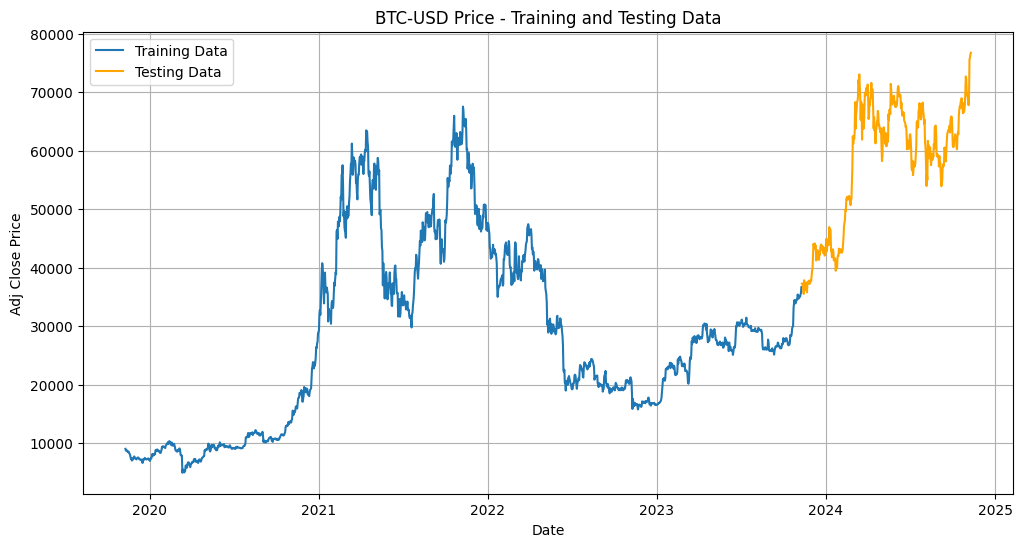

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


### Encode the date
# Read the CSV, treating the first column as the index
df = pd.read_csv('NEW.csv', index_col=0, header=[0, 1])

# Flatten the multi-level columns for easier access
df.columns = ['_'.join(col) for col in df.columns]

# Reset the index to make 'Date' a column
df = df.reset_index()  # This will create a 'Date' column from the index

# Convert the 'Date' column to datetime objects, handling errors
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows with invalid dates (NaT)
df = df.dropna(subset=['Date'])

# Extract the date part from the 'Date' column
df['Date_Only'] = df['Date'].dt.date

# Group by 'Date_Only' and calculate the mean 'Adj Close'
# Assuming the 'Adj Close' column is now named 'Adj Close_BTC-USD'
Real_Price = df.groupby('Date_Only')['Adj Close_BTC-USD'].mean()


### Split dataset into train and test sets (80% train, 20% test)
train_data, test_data = train_test_split(Real_Price, test_size=0.2, shuffle=False)

### Preprocess the data by reshaping it
training_set = train_data.values
training_set = np.reshape(training_set, (len(training_set), 1))

testing_set = test_data.values
testing_set = np.reshape(testing_set, (len(testing_set), 1))

### Plotting the training and testing data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data.values, label='Training Data')
plt.plot(test_data.index, test_data.values, label='Testing Data', color='orange')
plt.xlabel('Date')
plt.ylabel('Adj Close Price')
plt.title('BTC-USD Price - Training and Testing Data')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0567
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0027
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0022
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0023
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0016
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0017
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0015
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0014
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0014
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0012
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0012
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0012
Epoch 13/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0010
Epoch 14/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 9.4662e-04
Epoch 15/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 9.00

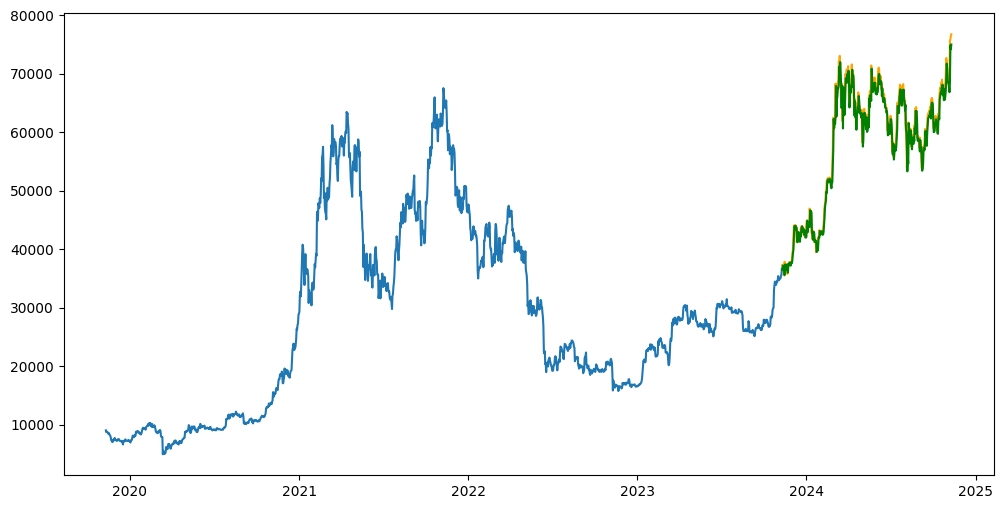

In [ ]:
!pip install -U -q Pydrive
!pip install -U -q mlflow

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense

# ... (Previous code for data preparation and splitting remains the same) ...

### Preprocess the data by reshaping it
training_set = train_data.values
training_set = np.reshape(training_set, (len(training_set), 1))

testing_set = test_data.values
testing_set = np.reshape(testing_set, (len(testing_set), 1))

### Feature Scaling
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

### Creating a data structure with 60 timesteps and 1 output
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i - 60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

### Reshaping
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

### Building the LSTM
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=50))
regressor.add(Dense(units=1))

### Compiling the LSTM
regressor.compile(optimizer='adam', loss='mean_squared_error')

### Fitting the LSTM to the Training set
regressor.fit(X_train, y_train, epochs=100, batch_size=32)

### Making the predictions and visualising the results
dataset_total = pd.concat((train_data, test_data), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_data) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i - 60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

### Calculate MSE and R2 score
predicted_train = regressor.predict(X_train)
predicted_train = sc.inverse_transform(predicted_train)

train_mse = mean_squared_error(training_set[60:], predicted_train)
test_mse = mean_squared_error(testing_set, predicted_stock_price)

train_r2 = r2_score(training_set[60:], predicted_train)
test_r2 = r2_score(testing_set, predicted_stock_price)

print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score: {test_r2:.4f}")

### Plotting the training and testing data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data.values, label='Training Data')
plt.plot(test_data.index, test_data.values, label='Testing Data', color='orange')
plt.plot(test_data.index, predicted_stock_price, label='Predicted Stock Price', color='green')

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ... (Previous code for data preparation and splitting remains the same) ...

### Preprocess the data by reshaping it
training_set = train_data.values
training_set = np.reshape(training_set, (len(training_set), 1))

testing_set = test_data.values
testing_set = np.reshape(testing_set, (len(testing_set), 1))

# ... (LSTM model training code - you'll need to add this part) ...

# Assuming 'predicted_train' and 'predicted_test' are the model's predictions
# for the training and testing sets, respectively.

### Calculate MSE and R2 score
# Use training_set[60:] to match the size of predicted_train
train_mse = mean_squared_error(training_set[60:], predicted_train)
test_mse = mean_squared_error(testing_set, predicted_stock_price)

train_r2 = r2_score(training_set[60:], predicted_train)
test_r2 = r2_score(testing_set, predicted_stock_price)

print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score: {test_r2:.4f}")

# ... (Plotting code remains the same) ...

Training MSE: 1396380.7373
Testing MSE: 3061158.7177
Training R2 Score: 0.9939
Testing R2 Score: 0.9734


In [ ]:
### define the RNN model
### instantiate the RNN model object
regr = Sequential()

### add the input and LSTM layers
regr.add(LSTM(units =4, activation ='sigmoid', input_shape =(None, 1)))

### add the output layer
regr.add(Dense(units =1))

### compile the RNN
regr.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['accuracy'])

### fit the model on the training set
regr.fit(X_train, y_train, batch_size =5, epochs =150)

### log the keras model with mlflow
with mlflow.start_run() as run:
  mlflow.keras.log_model(regr, "Bitcoin Price Prediction")

Epoch 1/150


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 2.0867e-04 - loss: 0.2609
Epoch 2/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 6.1617e-04 - loss: 0.0597
Epoch 3/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0022 - loss: 0.0517
Epoch 4/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 1.3513e-04 - loss: 0.0414
Epoch 5/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0022 - loss: 0.0284
Epoch 6/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0020 - loss: 0.0127
Epoch 7/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0013 - loss: 0.0040
Epoch 8/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.0020 - loss: 0.0015
Epoch 9/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 7.7837e-04 - loss: 0.0012
Epoch 10/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 4.7112e-04 - loss: 0.0011
Epoch 11/150
281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.0017 - loss: 0.0011
Epoch 12/150
281/281 ━

2024/11/13 06:03:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2024/11/13 06:03:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [ ]:
import mlflow
import os
import numpy as np

# ... Your existing model code ...

# Create a sample input
input_example = np.array([[0.5]])  # Example, adjust shape based on your model input
input_example = input_example.reshape(1, 1, 1)  # Assuming shape (samples, timesteps, features)

# Log the model with the input example using mlflow.keras.log_model
with mlflow.start_run() as run:
    # Log the model, specifying the model directory
    mlflow.keras.log_model(
        regr,
        "model", # changed this to a subdirectory inside the artifacts directory
        input_example=input_example,
    )

    # Get the artifact URI for the current run
    artifact_uri = mlflow.get_artifact_uri()

    # Construct the full path to the model directory
    model_dir = os.path.join(artifact_uri, "model")

    # Create the 'model' directory if it doesn't exist
    os.makedirs(model_dir, exist_ok=True)

2024/11/13 06:21:02 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/tmpuug5mtqb/model/input_example.json'

In [ ]:
### create predictions on the test set
test_set = df_test.values
inputs = np.reshape(test_set, (len(test_set), 1))
inputs = sc.transform(inputs)
inputs = np.reshape(inputs, (len(inputs), 1, 1))
predicted_BTC_price = regr.predict(inputs)
predicted_BTC_price = sc.inverse_transform(predicted_BTC_price)

print("Test set after reshaping:")
print('')
print(inputs)
print('')
print(inputs.shape)
print('')
print("Scaled inputs:")
print('')
print(inputs)
print('')
print("Reshaped inputs:")
print('')
print(inputs)
print('')
print(inputs.shape)
print('')
print("Predicted BTC price: ", predicted_BTC_price)
print('')
print("Scaled predicted BTC price: ", predicted_BTC_price)
print('')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
Test set after reshaping:

[[[0.76864801]]

 [[0.79488382]]

 [[0.77019743]]

 [[0.77813303]]

 [[0.751544  ]]

 [[0.71907232]]

 [[0.72187552]]

 [[0.73218019]]

 [[0.76415614]]

 [[0.77339341]]

 [[0.76890763]]

 [[0.78041561]]

 [[0.81630156]]

 [[0.80798916]]

 [[0.79591674]]

 [[0.78137719]]

 [[0.81244381]]

 [[0.83213383]]

 [[0.85108444]]

 [[0.85479181]]

 [[0.85775548]]

 [[0.8614827 ]]

 [[0.8568006 ]]

 [[0.87107353]]

 [[0.8540602 ]]

 [[0.88397936]]

 [[0.89292988]]

 [[0.89435377]]

 [[0.89064897]]

 [[0.85679619]]]

(30, 1, 1)

Scaled inputs:

[[[0.76864801]]

 [[0.79488382]]

 [[0.77019743]]

 [[0.77813303]]

 [[0.751544  ]]

 [[0.71907232]]

 [[0.72187552]]

 [[0.73218019]]

 [[0.76415614]]

 [[0.77339341]]

 [[0.76890763]]

 [[0.78041561]]

 [[0.81630156]]

 [[0.80798916]]

 [[0.79591674]]

 [[0.78137719]]

 [[0.81244381]]

 [[0.83213383]]

 [[0.85108444]]

 [[0.85479181]]

 [[0.85775548]]

 [[0.8614827 ]]

 [[0.8568006 ]]

 [[0

In [ ]:
### get evaluation of the model predictions
model_evaluation = regr.evaluate(inputs, predicted_BTC_price)

print("Model evaluation is: ", model_evaluation)
print('')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.0000e+00 - loss: 3654983680.0000
Model evaluation is:  [3654983680.0, 0.0]



Visualize the results:



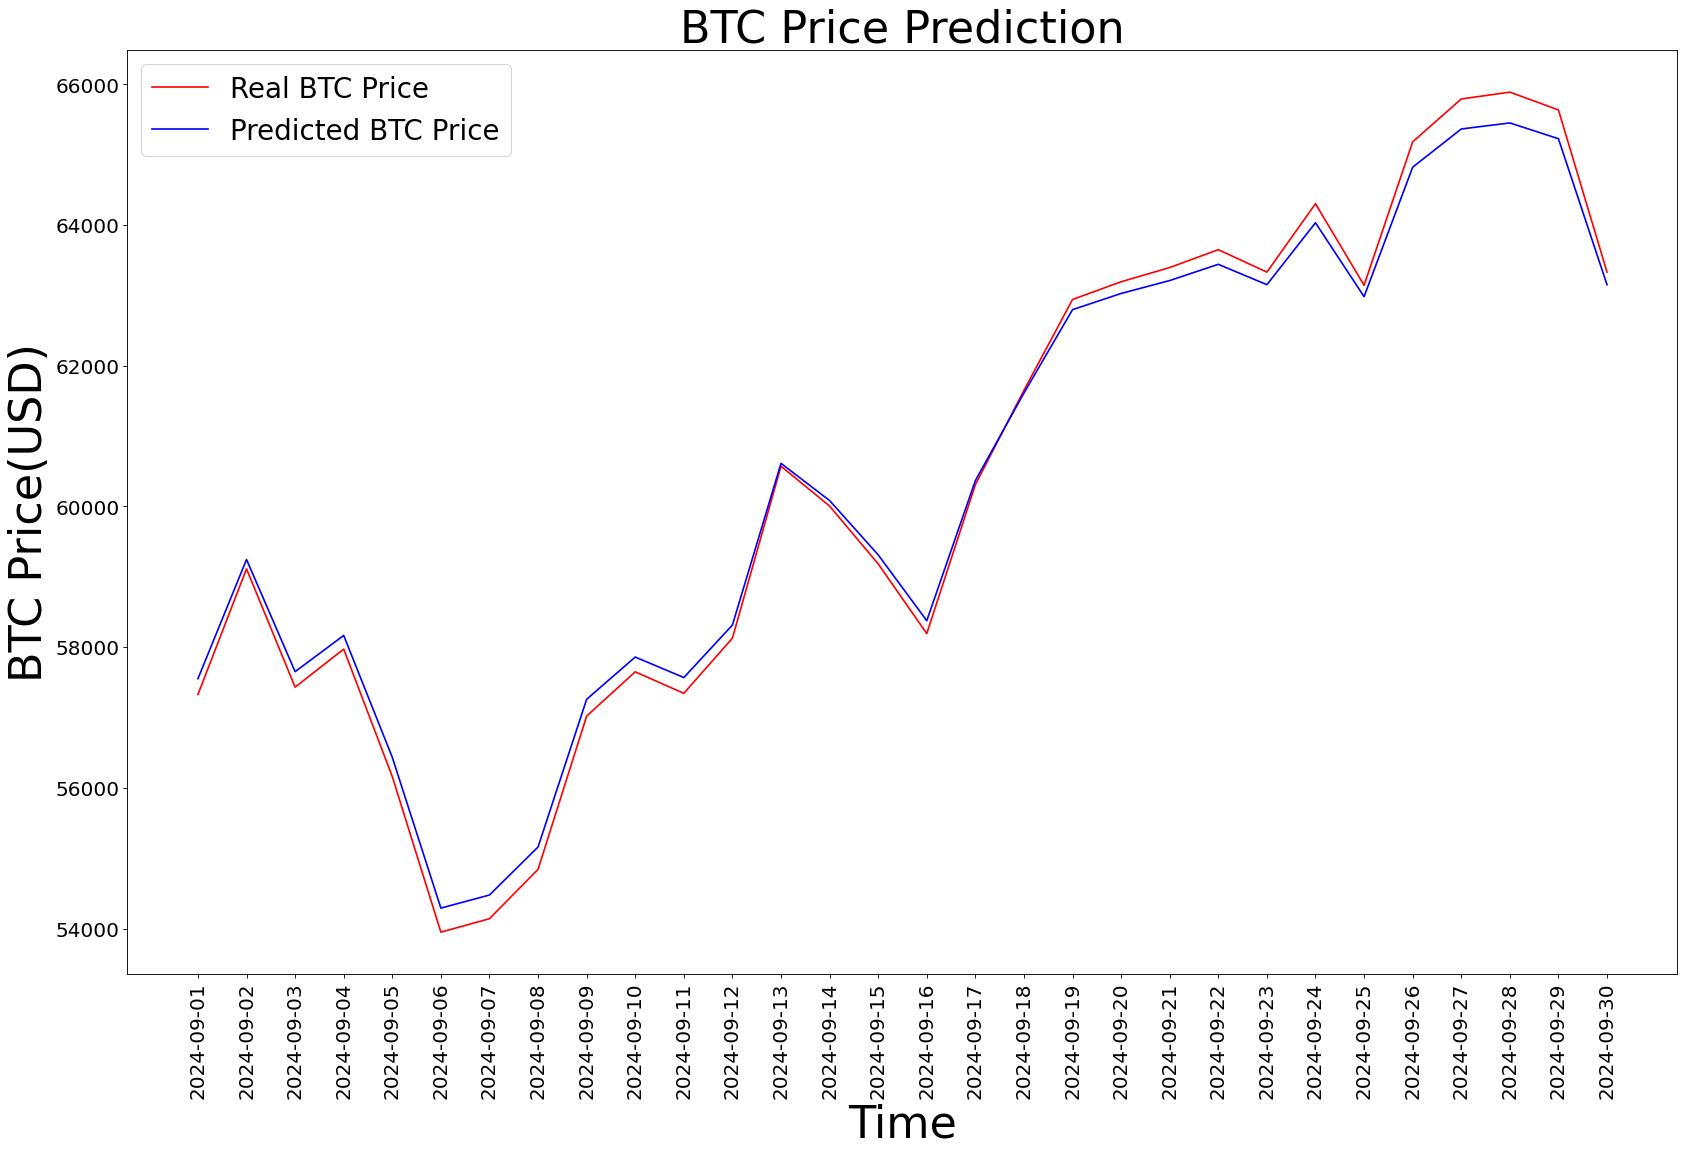

In [ ]:
### visualize the results
print("Visualize the results:")
print('')

### plot the actual and predicted prices
plt.figure(figsize =(25, 15), dpi =80, facecolor ='w', edgecolor ='k')
ax = plt.gca()
plt.plot(test_set, color = 'red', label = "Real BTC Price")
plt.plot(predicted_BTC_price, color = 'blue', label = "Predicted BTC Price")
plt.title("BTC Price Prediction", fontsize = 40)

### reindex the 'df_test' dataframe
df_test = df_test.reset_index()
x = df_test.index

### set labels
# The column name is 'Date' and not 'date' after resetting the index.
#Change from labels = df_test['date']
labels = df_test['Date']

### set xticks
plt.xticks(x, labels, rotation = 'vertical')

### set fontsize for 'x' and 'y' ticks
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontsize(18)

for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontsize(18)

### set plot labels
plt.xlabel('Time', fontsize = 40)
plt.ylabel('BTC Price(USD)', fontsize = 40)

### set plot legend
plt.legend(loc = 2, prop = {'size' : 25})

### show the plot
plt.show()

Enter the start date (YYYY-MM-DD): 2024-09-01


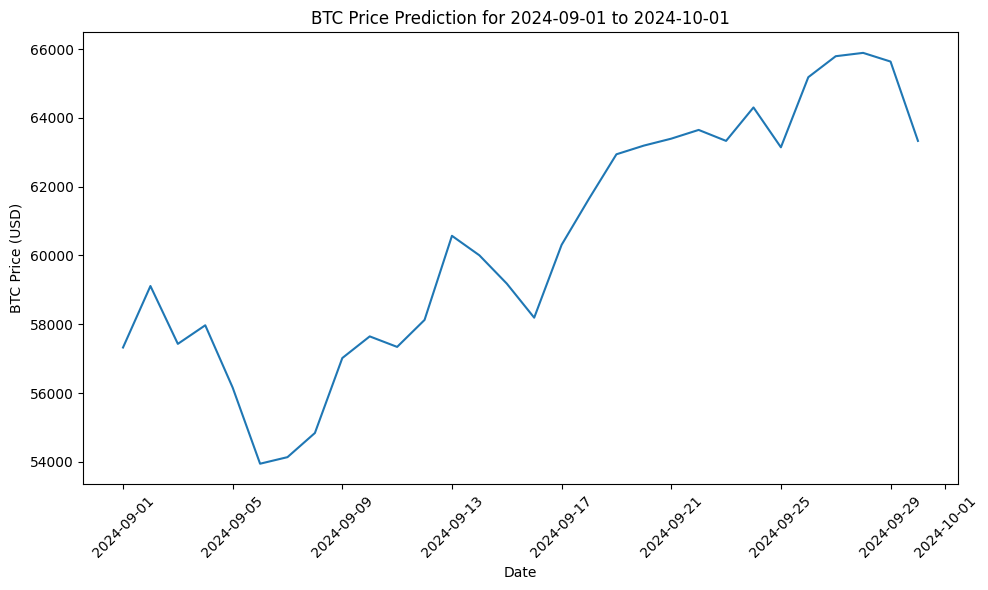

In [ ]:
# ploting the graph for the date which will given by user but upto 10 days

import pandas as pd
from matplotlib import pyplot as plt

# Assuming 'Real_Price' is defined as in your original code

def plot_specific_dates(start_date_str):
    try:
        start_date = pd.to_datetime(start_date_str).date()
        end_date = start_date + pd.Timedelta(days=30)

        # Filter Real_Price based on the specified date range
        filtered_price = Real_Price[(Real_Price.index >= start_date) & (Real_Price.index < end_date)]

        if filtered_price.empty:
          print("No data for the specified date range.")
          return

        plt.figure(figsize=(10, 6))
        plt.plot(filtered_price.index, filtered_price.values)

        plt.title(f"BTC Price Prediction for {start_date_str} to {end_date}")
        plt.xlabel("Date")
        plt.ylabel("BTC Price (USD)")
        plt.xticks(rotation=45)
        plt.tight_layout()  # Adjust layout to prevent labels from overlapping
        plt.show()

    except ValueError:
        print("Invalid date format. Please use YYYY-MM-DD.")


# Get user input for the start date
start_date_input = input("Enter the start date (YYYY-MM-DD): ")
plot_specific_dates(start_date_input)

In [ ]:
# ### visualize the results
# print("Visualize the results:")
# print('')

# ### plot the actual and predicted prices
# plt.figure(figsize =(25, 15), dpi =80, facecolor ='w', edgecolor ='k')
# ax = plt.gca()
# plt.plot(test_set, color = 'red', label = "Real BTC Price")
# plt.plot(predicted_BTC_price, color = 'blue', label = "Predicted BTC Price")
# plt.title("BTC Price Prediction", fontsize = 40)

# ### reindex the 'df_test' dataframe
# df_test = df_test.reset_index()
# x = df_test.index

# ### set labels
# labels = df_test['date']

# ### set xticks
# plt.xticks(x, labels, rotation = 'vertical')

# ### set fontsize for 'x' and 'y' ticks
# for tick in ax.xaxis.get_major_ticks():
#     tick.label1.set_fontsize(18)

# for tick in ax.yaxis.get_major_ticks():
#     tick.label1.set_fontsize(18)

# ### set plot labels
# plt.xlabel('Time', fontsize = 40)
# plt.ylabel('BTC Price(USD)', fontsize = 40)

# ### set plot legend
# plt.legend(loc = 2, prop = {'size' : 25})

# ### show the plot
# plt.show()

In [ ]:
### end of notebook
print("This is the end")

This is the end


In [ ]:
import pandas as pd
from datetime import datetime

# Load the data (assuming your data is in 'DAV.xlsx')
df = pd.read_excel('DAV.xlsx')

# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Function to predict the price based on the date
def predict_price(date_str):
    try:
        # Convert the input date string to a datetime object
        date = datetime.strptime(date_str, '%Y-%m-%d').date()  # Adjust the date format as needed

        # Filter out rows with invalid dates before finding the closest date
        valid_dates = df[df['Date'].notna()]

        # Find the closest date in the dataset (only considering valid dates)
        closest_date = min(valid_dates['Date'].dt.date, key=lambda x: abs(x - date))

        # Get the predicted price for the closest date
        predicted_price = df[df['Date'].dt.date == closest_date]['Adj Close'].iloc[0]
        return predicted_price

    except ValueError:
        return "Invalid date format. Please use YYYY-MM-DD."
    except IndexError:
        return "Date not found in dataset."
    except TypeError:
        return "Invalid date or missing data."  # Handle potential TypeError from NaT

# Get the user's input
date_input = input("Enter the date (YYYY-MM-DD): ")

# Predict the price
predicted_price = predict_price(date_input)

# Print the result
print(f"The predicted price for {date_input} is: {predicted_price}")

Enter the date (YYYY-MM-DD): 2024-10-01
The predicted price for 2024-10-01 is: 63329.5


In [ ]:
!pip freeze